# Test-Retest Analysis

This notebook reproduces the human test–retest accuracy reported by
[Toubia et al. (2025)](https://arxiv.org/html/2505.17479#S3).


In [1]:
%load_ext jupyter_black

In [2]:
import json
import re

import matplotlib.pyplot as plt
import pandas as pd
from datasets import Value, load_dataset

DATASET_ID = "LLM-Digital-Twin/Twin-2K-500"

In [3]:
from huggingface_hub import hf_hub_download

from behavior_modeling.data import answer_blocks_to_frame
from behavior_modeling.evaluation import (
    TWIN2K500_ANCHORING_GROUPS,
    calculate_test_retest,
    get_twin2k500_response_ranges,
    get_twin2k500_task_mapping,
)

## Load the wave split and question catalog

In [4]:
wave_split = load_dataset(DATASET_ID, "wave_split", split="data").cast_column(
    "pid", Value("string")
)

catalog_path = hf_hub_download(
    repo_id=DATASET_ID,
    repo_type="dataset",
    filename=("question_catalog_and_human_response_csv/" "question_catalog.json"),
)
with open(catalog_path, encoding="utf-8") as file:
    question_catalog = json.load(file)

## Convert paired answer blocks in memory

In [5]:
earlier_responses = answer_blocks_to_frame(
    wave_split,
    field="wave4_Q_wave1_3_A",
    question_catalog=question_catalog,
)
wave4_responses = answer_blocks_to_frame(
    wave_split,
    field="wave4_Q_wave4_A",
    question_catalog=question_catalog,
)

assert earlier_responses.index.equals(wave4_responses.index)
assert earlier_responses.columns.equals(wave4_responses.columns)
print("Earlier responses:", earlier_responses.shape)
print("Wave-4 responses:", wave4_responses.shape)

Earlier responses: (2058, 126)
Wave-4 responses: (2058, 126)


## Test-Retest Accuracy

Test-Retest Accuracy measures how reproducbile the observed human answers are. It measures each participant's wave 4 response against their reponse to the same questions in wave 1-3 (held out).

For binary questions, the score is based on exact match:

$$
s = \mathbb{1}[y = \hat{y}]
$$

For non-binary questions, the score is:

$$
s = 1 - \frac{|y - \hat{y}|}{U - L}
$$

where:

- $y$ is the ground-truth response,
- $\hat{y}$ is the predicted response,
- $L$ is the minimum valid response value, and
- $U$ is the maximum valid response value.

A score of 1 indicates an exact match, while lower scores indicate greater disagreement between the predicted and ground-truth responses.

Question-level scores are first averaged within each behavioral task. The task-level scores are then averaged so that each of the 17 behavioral tasks contributes equally to the overall accuracy.


In [6]:
result = calculate_test_retest(
    earlier_responses,
    wave4_responses,
    response_ranges=get_twin2k500_response_ranges(),
    task_mapping=get_twin2k500_task_mapping(),
    anchoring_groups=TWIN2K500_ANCHORING_GROUPS,
)

summary = pd.Series(
    {
        "paper_style_accuracy_pct": 100 * result.overall_accuracy,
        "atomic_exact_match_pct": 100 * result.exact_match_accuracy,
        "participants": result.n_participants,
        "tasks": result.n_tasks,
        "scored_responses": result.n_responses,
    }
)
display(summary)

paper_style_accuracy_pct        81.731664
atomic_exact_match_pct          62.801865
participants                  2058.000000
tasks                           17.000000
scored_responses            193464.000000
dtype: float64

## Test-Retest Accuracy by Task

In [7]:
task_summary = result.task_summary.copy()
task_summary["accuracy_pct"] = 100 * task_summary["accuracy"]
task_summary["exact_match_pct"] = 100 * task_summary["exact_match_accuracy"]
display(task_summary.sort_values("accuracy_pct"))

,task,accuracy,exact_match_accuracy,valid_comparison_rate,participants,responses,accuracy_pct,exact_match_pct
6,denominator neglect,0.721574,0.721574,1.0,2058,2058,72.157434,72.157434
0,Allais,0.740525,0.740525,1.0,2058,2058,74.052478,74.052478
15,prob matching vs. max,0.747619,0.747619,1.0,2058,16476,74.761905,74.761905
16,sunk cost fallacy,0.788435,0.327988,1.0,2058,2058,78.843537,32.798834
2,absolute vs. relative savings,0.791545,0.791545,1.0,2058,2058,79.154519,79.154519
8,framing problem,0.802721,0.379495,1.0,2058,2058,80.272109,37.949466
12,omission,0.805799,0.531584,1.0,2058,2058,80.579851,53.158406
5,conjunction problem (Linda),0.824069,0.389861,1.0,2058,6174,82.406868,38.986071
9,less is more,0.831495,0.516197,1.0,2058,6174,83.149498,51.619695
4,base rate,0.834558,0.277940,1.0,2058,2058,83.455782,27.793975


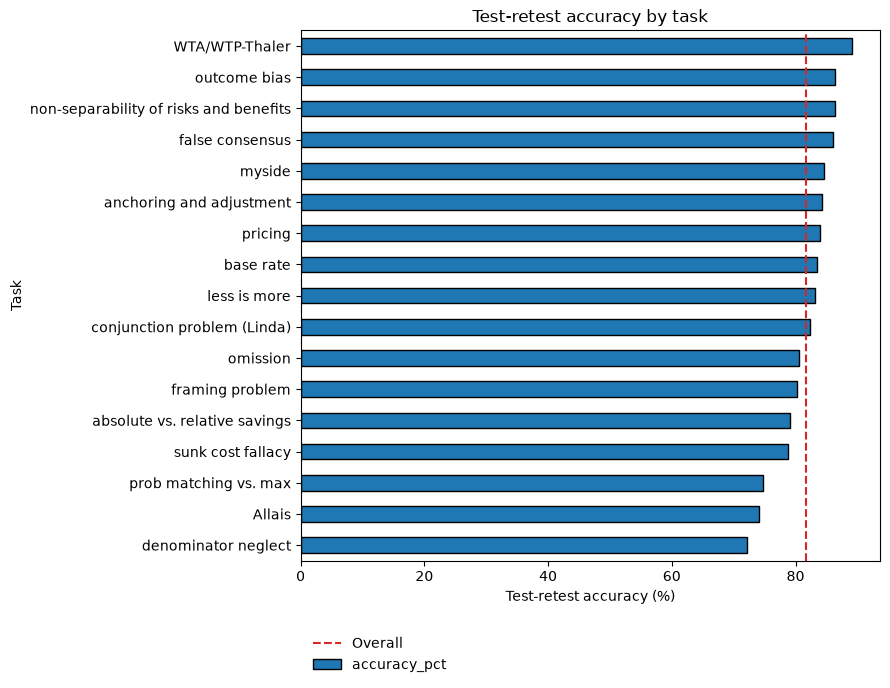

In [8]:
plot_data = task_summary.sort_values("accuracy_pct")
ax = plot_data.plot.barh(
    x="task",
    y="accuracy_pct",
    legend=False,
    edgecolor="black",
    figsize=(9, 7),
)
ax.axvline(
    100 * result.overall_accuracy,
    color="tab:red",
    linestyle="--",
    label="Overall",
)
ax.set_title("Test-retest accuracy by task")

ax.set_xlabel("Test-retest accuracy (%)")
ax.set_ylabel("Task")
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0, -0.12),
    frameon=False,
)
plt.tight_layout()
plt.show()

## Test-retest Summary

We reproduced test-retest accuracy of 81.73%, closely matching the original paper's 81.72%. The test-retest accuracy varies across behavioral tasks. This indicates that some responses are more stable than others. 

It is also worth mentioning that test-retest accuracy reflects how consistently humans reproduce their own answers and is not a strict upper bound for model evaluation.  

## Test–retest Benchmark

For a fair comparison with model performance, the test–retest accuracy on the same test participants and questions used for model evaluation are calculated

In [9]:
from datasets import load_from_disk

participant_splits = load_from_disk("../data/processed/twin2k500_compact")

train_participants = participant_splits["train"]
validation_participants = participant_splits["validation"]
test_participants = participant_splits["test"]

In [10]:
split_results = {}
split_summaries = []

for split_name in [
    "train",
    "validation",
    "test",
]:
    split_dataset = participant_splits[split_name]

    earlier_responses = answer_blocks_to_frame(
        split_dataset,
        field="wave4_Q_wave1_3_A",
        question_catalog=question_catalog,
    )

    later_responses = answer_blocks_to_frame(
        split_dataset,
        field="wave4_Q_wave4_A",
        question_catalog=question_catalog,
    )

    # Confirm that both measurements contain the same
    # participants and response columns.
    assert earlier_responses.index.equals(later_responses.index)
    assert earlier_responses.columns.equals(later_responses.columns)

    result = calculate_test_retest(
        earlier_responses,
        later_responses,
        response_ranges=(get_twin2k500_response_ranges()),
        task_mapping=(get_twin2k500_task_mapping()),
        anchoring_groups=(TWIN2K500_ANCHORING_GROUPS),
    )

    split_results[split_name] = result

    split_summaries.append(
        {
            "split": split_name.title(),
            "test_retest_accuracy_pct": (100 * result.overall_accuracy),
            "exact_match_accuracy_pct": (100 * result.exact_match_accuracy),
            "participants": (result.n_participants),
            "tasks": result.n_tasks,
            "scored_responses": (result.n_responses),
        }
    )

In [11]:
split_test_retest_summary = pd.DataFrame(split_summaries).set_index("split").round(2)

split_test_retest_summary

,test_retest_accuracy_pct,exact_match_accuracy_pct,participants,tasks,scored_responses
split,,,,,
Train,81.77,62.94,1440,17,135404
Validation,81.68,62.13,205,17,19244
Test,81.65,62.67,413,17,38816


## Test-retest Benchmark 5000
For direct comparison with the model, we also
calculate test–retest accuracy using the same 5,000 test examples used in the intial model evaluation.


### Load Evaluation Data

In [12]:
SAMPLE_SIZE = 5_000
SAMPLE_SEED = 42

PROMPT_DATA_DIR = "../data/processed/prompts/qwen25_05b_compact_full"

prompt_splits = load_from_disk(PROMPT_DATA_DIR)

test_prompts = prompt_splits["test"]

sampled_test_prompts = test_prompts.shuffle(seed=SAMPLE_SEED).select(
    range(
        min(
            SAMPLE_SIZE,
            len(test_prompts),
        )
    )
)

print("Sampled examples:", len(sampled_test_prompts))
print(
    "Sampled participants:",
    len(set(sampled_test_prompts["pid"])),
)

Sampled examples: 5000
Sampled participants: 413


In [13]:
test_participants = participant_splits["test"]

earlier_test = answer_blocks_to_frame(
    test_participants,
    field="wave4_Q_wave1_3_A",
    question_catalog=question_catalog,
)

wave4_test = answer_blocks_to_frame(
    test_participants,
    field="wave4_Q_wave4_A",
    question_catalog=question_catalog,
)

assert earlier_test.index.equals(wave4_test.index)
assert earlier_test.columns.equals(wave4_test.columns)

In [14]:
import re
from collections import defaultdict


def normalize_name(value: object) -> str:
    return (
        re.sub(
            r"\s+",
            " ",
            str(value or ""),
        )
        .strip()
        .casefold()
    )


catalog_columns = {}

for catalog_item in question_catalog:
    key = (
        normalize_name(catalog_item.get("BlockName")),
        str(catalog_item.get("QuestionID") or ""),
    )

    columns = [
        str(column).upper() for column in (catalog_item.get("csv_columns") or [])
    ]

    if key in catalog_columns:
        raise ValueError(f"Duplicate catalog key: {key}")

    catalog_columns[key] = columns

In [15]:
selected_columns_by_pid = defaultdict(set)

for example in sampled_test_prompts:
    pid = str(example["pid"])

    key = (
        normalize_name(example["block_name"]),
        str(example["question_id"]),
    )

    if key not in catalog_columns:
        raise KeyError(f"Question not found in catalog: {key}")

    selected_columns_by_pid[pid].update(catalog_columns[key])

### Reproduce the model-evaluation sample

In [16]:
sample_mask = pd.DataFrame(
    False,
    index=earlier_test.index,
    columns=earlier_test.columns,
)

for pid, columns in selected_columns_by_pid.items():
    available_columns = [column for column in columns if column in sample_mask.columns]

    if not available_columns:
        raise ValueError(f"No scoreable columns found for PID {pid}")

    sample_mask.loc[
        pid,
        available_columns,
    ] = True

In [17]:
sample_mask = pd.DataFrame(
    False,
    index=earlier_test.index,
    columns=earlier_test.columns,
)

for pid, columns in selected_columns_by_pid.items():
    available_columns = [column for column in columns if column in sample_mask.columns]

    if not available_columns:
        raise ValueError(f"No scoreable columns found for PID {pid}")

    sample_mask.loc[
        pid,
        available_columns,
    ] = True

In [18]:
earlier_5000 = earlier_test.where(sample_mask)

wave4_5000 = wave4_test.where(sample_mask)

# Remove participants and columns that were not selected.
selected_participants = sample_mask.any(axis=1)
selected_response_columns = sample_mask.any(axis=0)

earlier_5000 = earlier_5000.loc[
    selected_participants,
    selected_response_columns,
]

wave4_5000 = wave4_5000.loc[
    selected_participants,
    selected_response_columns,
]

### Match sampled questions to scored response columns


In [19]:
test_retest_5000 = calculate_test_retest(
    earlier_5000,
    wave4_5000,
    response_ranges=(get_twin2k500_response_ranges()),
    task_mapping=(get_twin2k500_task_mapping()),
    anchoring_groups=(TWIN2K500_ANCHORING_GROUPS),
)

matched_summary = pd.Series(
    {
        "sampled_question_examples": len(sampled_test_prompts),
        "participants": (test_retest_5000.n_participants),
        "tasks": test_retest_5000.n_tasks,
        "scored_responses": (test_retest_5000.n_responses),
        "test_retest_accuracy_pct": (100 * test_retest_5000.overall_accuracy),
        "exact_match_accuracy_pct": (100 * test_retest_5000.exact_match_accuracy),
    }
).round(2)

matched_summary

sampled_question_examples    5000.00
participants                  413.00
tasks                          17.00
scored_responses             7375.00
test_retest_accuracy_pct       83.45
exact_match_accuracy_pct       63.32
dtype: float64